# K Nearest Neighbors (KNN)

## Binary Classification Task

### Load Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from collections import Counter
from sklearn.model_selection import train_test_split


### Define distance function

In [2]:
# Define the distance between two points 
def minkowski_distance(a, b, p=2):
    
    distance = np.sum(np.abs(a - b)**p, axis=1)**(1/p)
    
    return distance

### Define your KNN model

In [3]:
def knn_predict_class(X_train, y_train, X_test, k=5, p=2):
    
    # define an emty list to store predictions for test points
    preds = []

    # Loop over each test point
    for x in X_test:

        # compute the distance between each test point and all the train points
        d = minkowski_distance(X_train, x, p=p)  

        # sort the distance in an ascendin order
        idx = np.argsort(d)

        # get the top k nearest neighbors
        top_k_idx = idx[:k]

        # get labels for the top k idx
        labels = y_train[top_k_idx]

        # compute the number of labels per class
        counter = np.bincount(labels)

        # get the most common label
        vote = counter.argmax()
        
        # store the prediction for the test point in the prediction list
        preds.append(vote)
    
    # return the prediction list as numpy array
    return np.array(preds)


### Create Synthetic Data

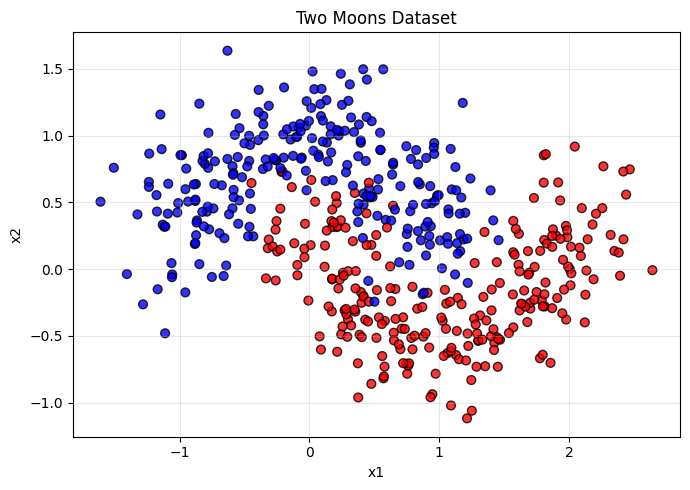

In [4]:
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)  # binary labels {0,1}

# Plot original data
plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k', s=40, alpha=0.8)
plt.title("Two Moons Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Split data into train and test

In [5]:
# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

### Define the Hyperparameters

In [6]:
k = 7 # 7 neighbors
p = 2  # Euclidean

### Apply KNN to generate predictions

In [7]:
# generate model predictions for all the grid
y_pred_test = knn_predict_class(X_train, y_train, X_test, k=k, p=p)
y_pred_train = knn_predict_class(X_train, y_train, X_train, k=k, p=p)

y_pred_test

array([1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [8]:
#Define the model decision boundary

# define a grid of test points
x1_min, x1_max = X[:,0].min()-0.5, X[:,0].max()+0.5
x2_min, x2_max = X[:,1].min()-0.5, X[:,1].max()+0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                       np.linspace(x2_min, x2_max, 300))
grid = np.concatenate((xx1.ravel().reshape(-1, 1), xx2.ravel().reshape(-1, 1)), axis=1)

# generate model predictions for all the grid
Z = knn_predict_class(X_train, y_train, grid, k=k, p=p).reshape(xx1.shape)

### Visualize Model Predictions and decision boundary

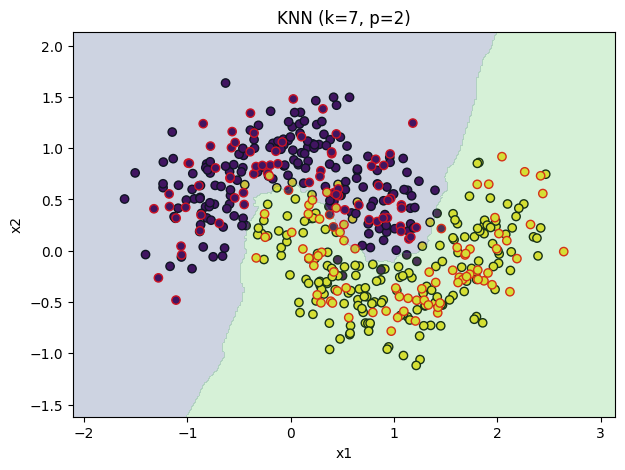

In [9]:
plt.figure(figsize=(7,5))
# Plot training data
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolor='k')
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, edgecolor='r')

# Plot decision boundary using the predefined grid
# countourf fills the spaces between contour lines.
# The levels argument tells Matplotlib where to draw the boundaries between color regions.
# [-0.5, 0.5] > Region colored for class 0
# [0.5, 1.5] > Region colored for class 1
# The decision boundary is drawn along the 0.5 contour line: the “middle” between class 0 and 1.
plt.contourf(xx1, xx2, Z, alpha=0.25, levels=[-0.5,0.5,1.5])

plt.title(f"KNN (k={k}, p={p})")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


### Evaluate model performance

In [10]:
from sklearn.metrics import accuracy_score


# evaluate your model on test data
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))


Train Accuracy: 0.96
Test Accuracy: 0.94


## Regression Task

### Load Libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt

### Define distance function

In [12]:
# Define the distance between two points 
def minkowski_distance(a, b, p=2):
    
    distance = np.sum(np.abs(a - b)**p, axis=1)**(1/p)
    
    return distance

### Define you KNN model

In [13]:
def knn_predict_reg(X_train, y_train, X_test, k=5, p=2):
    
    # define an emty list to store predictions for test points
    preds = []

    # Loop over each test point
    for x in X_test:

        # compute the distance between each test point and all the train points
        d = minkowski_distance(X_train, x, p=p)  

        # sort the distance in an ascendin order
        idx = np.argsort(d)

        # get the top k nearest neighbors
        top_k_idx = idx[:k]

        # get values for the top k idx
        values = y_train[top_k_idx]

        # compute the average of labels
        mean = np.mean(values)
        
        # store the prediction for the test point in the prediction list
        preds.append(mean)
    
    # return the prediction list as numpy array
    return np.array(preds)


### Create Synthetic data

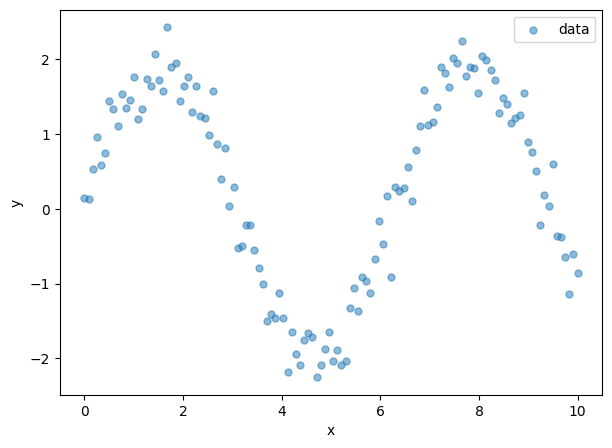

In [14]:
np.random.seed(42)
X = np.linspace(0, 10, 120).reshape(-1,1)
y = 2*np.sin(X).ravel() + np.random.normal(0, 0.3, size=X.shape[0])


plt.figure(figsize=(7,5))
plt.scatter(X, y, alpha=0.5, s=25, label="data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### Split data into train and test

In [15]:
# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Define the hyperparameters

In [16]:
k = 7 # 7 neighbors
p = 2  # Euclidean

### Apply KNN to generate predictions

In [17]:
# apply KNN model
y_pred_test = knn_predict_reg(X_train, y_train, X_test, k=7, p=2)
y_pred_train = knn_predict_reg(X_train, y_train, X_train, k=7, p=2)


### Visualize Model Predictions and decision boundary

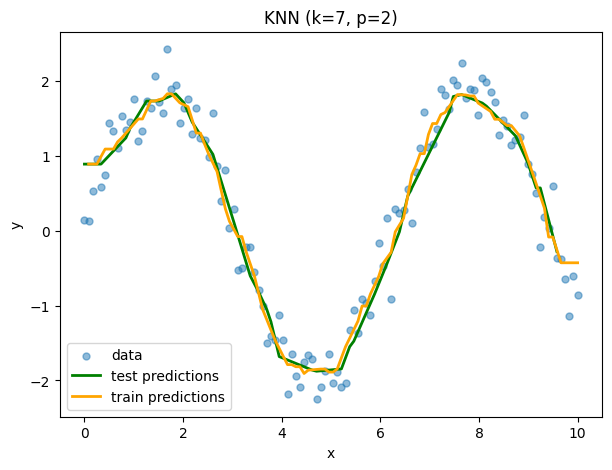

In [18]:
# sort the train points for plotting
sort_idx = np.argsort(X_train.ravel())         # indices that sort X_train
X_train_sorted = X_train[sort_idx]
y_pred_train_sorted = y_pred_train[sort_idx]

# sort the test points for plotting
sort_idx = np.argsort(X_test.ravel())         # indices that sort X_test
X_test_sorted = X_test[sort_idx]
y_pred_test_sorted = y_pred_test[sort_idx]

# visualize results
plt.figure(figsize=(7,5))
plt.scatter(X, y, alpha=0.5, s=25, label="data")
plt.plot(X_test_sorted, y_pred_test_sorted, linewidth=2, color='green', label="test predictions")
plt.plot(X_train_sorted, y_pred_train_sorted, linewidth=2, color='orange', label="train predictions")
plt.title(f"KNN (k={k}, p={p})")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### Evaluate model performance

In [19]:
from sklearn.metrics import root_mean_squared_error, r2_score



# Training Performance
train_rmse = root_mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print(' ***   Training Performance   ***')
print(f"RMSE: {train_rmse:.3f}")
print(f"R²: {train_r2:.3f}")

# Testing Performance
test_rmse = root_mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print(' ***   Testing Performance   ***')
print(f"RMSE: {test_rmse:.3f}")
print(f"R²: {test_r2:.3f}")

 ***   Training Performance   ***
RMSE: 0.288
R²: 0.952
 ***   Testing Performance   ***
RMSE: 0.327
R²: 0.939
